In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv("AirPassengers.csv", index_col='Month', parse_dates=['Month'])

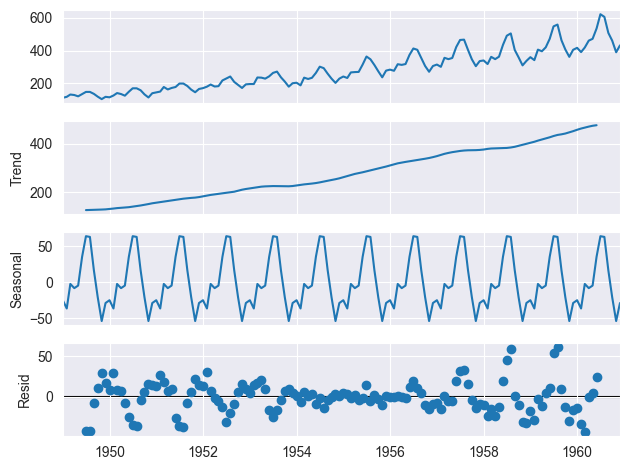

In [4]:
#производим декомпозицию временного ряда
decomposition = seasonal_decompose(df)
fig = decomposition.plot()
plt.show()

In [3]:
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv(
	"daily-total-female-births.csv",
    header=0,
    index_col=0
).squeeze("columns")

result = adfuller(df.values)

print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print("Critical Values:")

for key, value in result[4].items():
	print(f"\t{key}: {value:.3f}")

ADF Statistic: -4.808291253559767
p-value: 5.2434129901497877e-05
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571


In [4]:
import numpy as np
from statsmodels.tsa.ar_model import AutoReg

url='https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv'
df = pd.read_csv(url, sep=",")

In [5]:
result = adfuller(df['Consumption'].values)

if result[0] > result[4]['5%']:
    print ('Ряд нестационарен')
else:
    print ('Ряд стационарен')

Ряд стационарен


In [6]:
train_data = df['Consumption'][:len(df)-100]
test_data = df['Consumption'][len(df)-100:]

In [7]:
ar_model = AutoReg(train_data, lags=8).fit()
print(ar_model.summary())

                            AutoReg Model Results                             
Dep. Variable:            Consumption   No. Observations:                 4283
Model:                     AutoReg(8)   Log Likelihood              -24231.812
Method:               Conditional MLE   S.D. of innovations             70.058
Date:                Sat, 02 Aug 2025   AIC                          48483.625
Time:                        14:21:22   BIC                          48547.230
Sample:                             8   HQIC                         48506.095
                                 4283                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            121.2792     14.444      8.397      0.000      92.969     149.589
Consumption.L1     0.6393      0.013     47.751      0.000       0.613       0.666
Consumption.L2    -0.0966      0.011

In [8]:
pred = ar_model.predict(start=len(train_data), end=(len(df)-1), dynamic=False)

In [10]:
df = pd.read_csv("tovar_moving.csv",  index_col=['date'], parse_dates=['date'])
df.head()

,qty
date,
2009-12-25,72314.0
2009-12-26,66586.0
2009-12-27,125199.0
2009-12-28,91544.0
2009-12-29,76995.0


In [11]:
test_df = df.iloc[-1]
train_df = df.iloc[:-1]

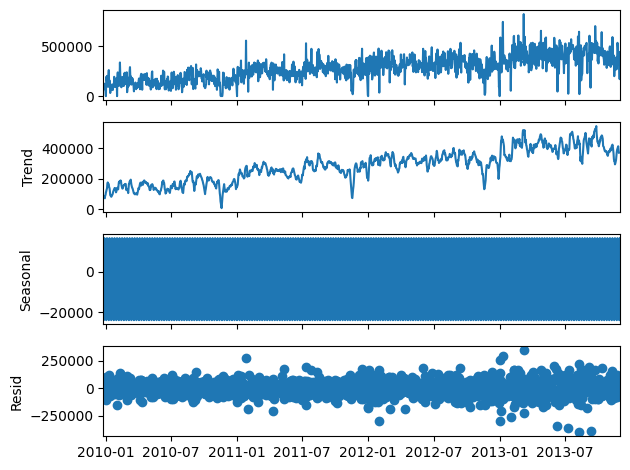

In [12]:
from matplotlib import pyplot

decomposition = seasonal_decompose(df, model='additive')
decomposition.plot()
pyplot.show()

In [15]:
from statsmodels.tsa.api import SimpleExpSmoothing

ses = SimpleExpSmoothing(train_df)
alpha = 0.7
model = ses.fit(smoothing_level = alpha, optimized = False)
exp_pred = model.forecast(1)
print(exp_pred)
print(test_df)

2013-12-02    225015.522647
Freq: D, dtype: float64
qty    423846.0
Name: 2013-12-02 00:00:00, dtype: float64


/Users/dmitryvokhmin/Desktop/courses/DS/ds-python-8/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [16]:
import statsmodels.api as sm

def stat_test(df):
    test = sm.tsa.adfuller(df)
    print ('adf: ', test[0] )
    print ('p-value: ', test[1])
    print('Critical values: ', test[4])
    if test[0]> test[4]['5%']:
        print ('есть единичные корни, ряд не стационарен')
    else:
        print ('единичных корней нет, ряд стационарен')

stat_test(train_df)

adf:  -2.255302641033781
p-value:  0.186789031234171
Critical values:  {'1%': -3.434973278556316, '5%': -2.8635818545830376, '10%': -2.567857072940785}
есть единичные корни, ряд не стационарен


In [25]:
otg1diff = train_df.diff(periods=1).dropna()
stat_test(otg1diff)

adf:  -13.780727380503732
p-value:  9.307227521341916e-26
Critical values:  {'1%': -3.434973278556316, '5%': -2.8635818545830376, '10%': -2.567857072940785}
единичных корней нет, ряд стационарен


In [26]:
train_df = otg1diff

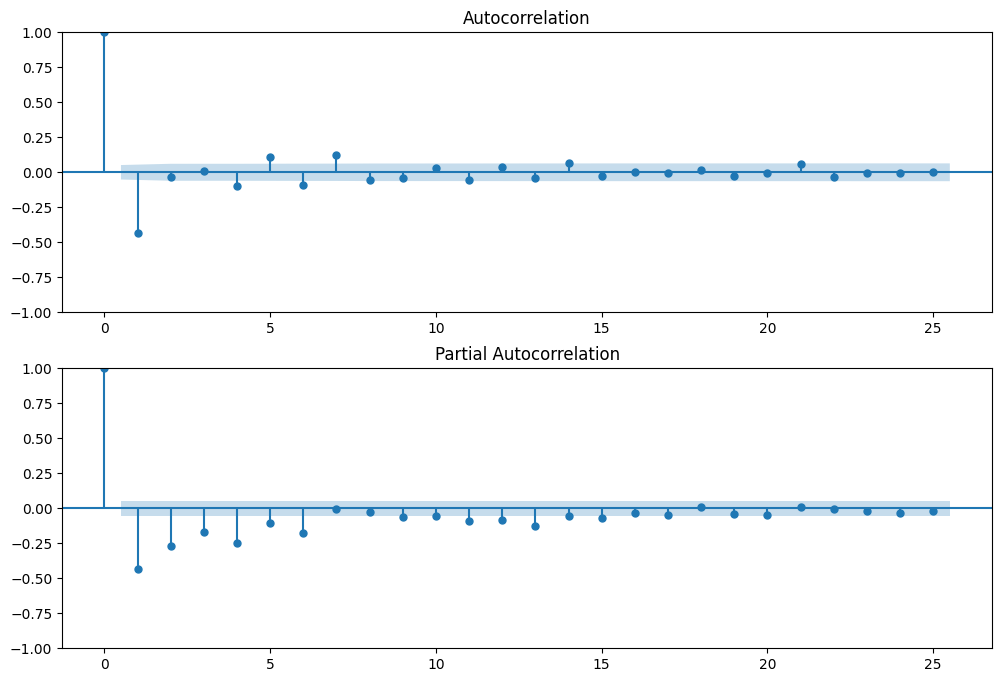

In [27]:
from matplotlib import pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(train_df.values.squeeze(), lags=25, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(train_df, lags=25, ax=ax2)

In [28]:
p = 6

ar_model = AutoReg(train_df, lags=p).fit()

ar_pred = ar_model.predict(start=len(train_df), end=(len(train_df)), dynamic=False)
ar_pred

/Users/dmitryvokhmin/Desktop/courses/DS/ds-python-8/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/dmitryvokhmin/Desktop/courses/DS/ds-python-8/.venv/lib/python3.11/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


2013-12-02    183773.199142
Freq: D, dtype: float64

In [30]:
from sklearn.metrics import mean_squared_error

mean_squared_error(test_df, ar_pred), mean_squared_error(test_df, exp_pred)

(57634949711.83132, 39533558724.37031)